In [1]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# Define stock tickers
tickers = ["AAPL","MSFT", "JPM", "XOM", "SPY"]
#Download adjusted closing prices
data = yf.download(tickers,start="2020-01-01")["Close"]
#Display first rows
data.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,JPM,MSFT,SPY,XOM
Date,,,,,
2020-01-02,72.333862,118.430313,152.158401,296.888092,52.947025
2020-01-03,71.630646,116.867470,150.263779,294.640106,52.521358
2020-01-06,72.201416,116.774544,150.652176,295.764130,52.924618
2020-01-07,71.861855,114.789307,149.278503,294.932526,52.491497
2020-01-08,73.017838,115.684792,151.656311,296.504395,51.699909


In [3]:
#Save the stock prices
data.to_csv("../data/stock_prices.csv")

In [4]:
#Calculate the daily returns
returns = data.pct_change().dropna()
#Display returns
returns.head()

Ticker,AAPL,JPM,MSFT,SPY,XOM
Date,,,,,
2020-01-03,-0.009722,-0.013196,-0.012452,-0.007572,-0.008039
2020-01-06,0.007968,-0.000795,0.002585,0.003815,0.007678
2020-01-07,-0.004703,-0.017001,-0.009118,-0.002812,-0.008184
2020-01-08,0.016086,0.007801,0.015929,0.005330,-0.015080
2020-01-09,0.021240,0.003651,0.012493,0.006781,0.007656


In [5]:
#Save stock returns data
returns.to_csv("../data/daily_returns.csv")

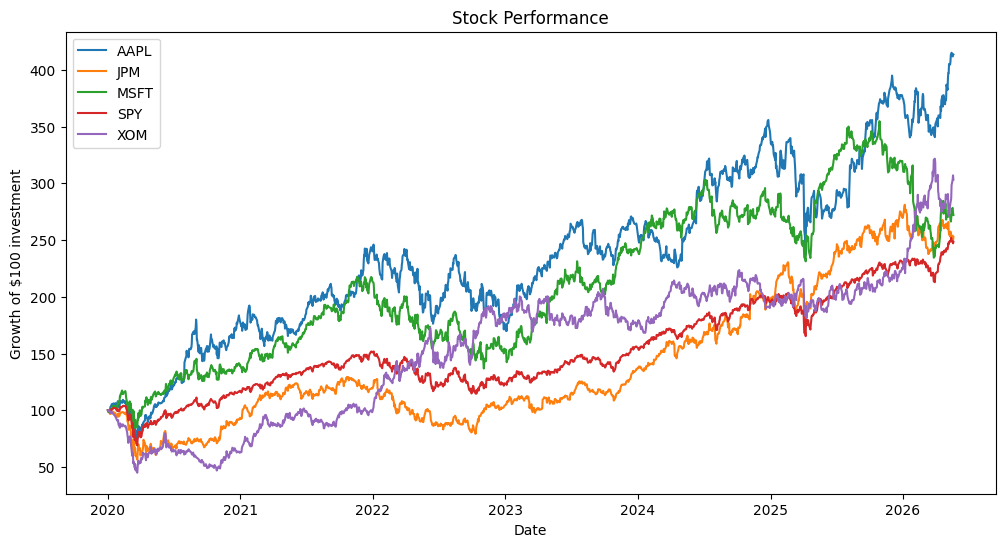

In [7]:
#Normalising the stock prices, $100
normalised = data / data.iloc[0] * 100
#Creating plot to compare the differences in stocks
plt. figure(figsize=(12,6))
for column in normalised.columns:
    plt.plot(normalised.index, normalised[column], label=column)
plt.title("Stock Performance")
plt.xlabel("Date")
plt.ylabel("Growth of $100 investment")
plt.legend()

#Save plot
plt.savefig("../visuals/normalised_performance.png")
plt.show()

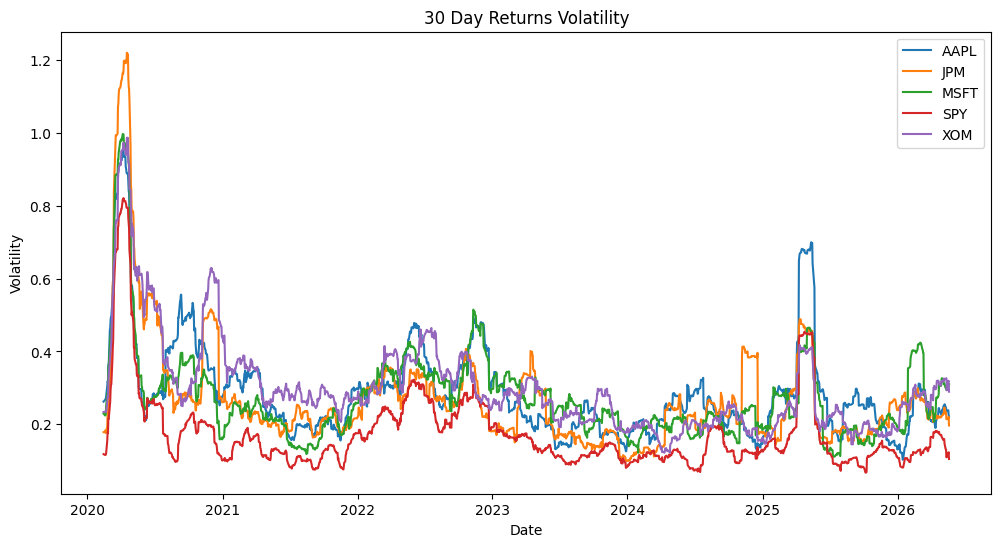

In [8]:
#Calculating the volatility of stock returns
rolling_vol = returns.rolling(window=30).std() * (252**0.5)
#Creating volatility plot
plt.figure(figsize=(12,6))
for column in rolling_vol.columns:
    plt.plot(rolling_vol.index, rolling_vol[column], label=column)
plt.title("30 Day Returns Volatility")
plt.xlabel("Date")
plt.ylabel("Volatility")
plt.legend()
#Saving volatility plot
plt.savefig("../visuals/rolling_volatility.png")
plt.show()

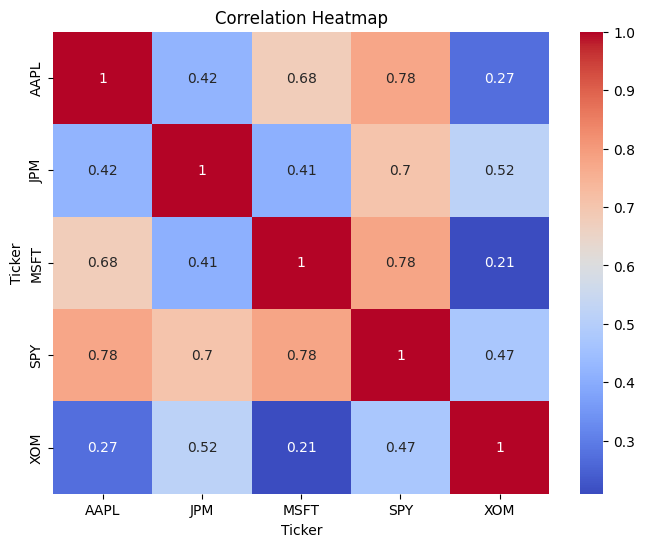

In [9]:
#Correlation Matrix
corr_matrix = returns.corr()
#Creating the heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
#Saving the heatmap
plt.savefig("../visuals/correlation_heatmap.png")
plt.show()

# Market Analysis

## Objective
In this project I analysed market performance, volatility, and correlation across multiple sectors using financial data. This analysis compares how different equities behaved over time and evaluates the relationship between return, risk, and diversification.

## Assets Analysed
- Apple (AAPL)
- Microsoft (MSFT)
- JPMorgan (JPM)
- Exxon Mobil (XOM)
- SPY ETF

## Key Insights

### Performance Analysis
AAPL and MSFT generated the strongest long-term cumulative returns, reflecting strong growth within the technology sector during this period. SPY demonstrated steadier performance due to its diversified market exposure, while JPM displayed weaker cumulative performance relative to technology equities.

### Volatility Analysis
The technology sector exhibited higher volatility during the periods of market stress, particularly during major market disruptions. SPY displayed more stable behaviour overall due to diversification benefits.

### Correlation Analysis
AAPL and MSFT showed high correlations with SPY, indicating that there is a strong alignment with broader market movements. XOM demonstrated lower correlations with technology equities, suggesting potential diversification benefits from energy sector.